In [1]:
import torch

In [97]:
from IPython.display import Image

# 矩阵创建

In [2]:
# 从列表、数组创建
a = torch.tensor([[1,2],[3,4]])
print(a)

tensor([[1, 2],
        [3, 4]])


In [3]:
# 全零矩阵
a = torch.zeros(3,4)
print(a)

tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])


In [4]:
# 全一矩阵
a = torch.ones(3,4)
print(a)

tensor([[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]])


In [5]:
# 单位矩阵
a = torch.eye(3)
print(a)

tensor([[1., 0., 0.],
        [0., 1., 0.],
        [0., 0., 1.]])


In [6]:
# 均匀分布
a = torch.rand(3,4)
print(a)

tensor([[0.0888, 0.1381, 0.6493, 0.9038],
        [0.1658, 0.3805, 0.4105, 0.2872],
        [0.4546, 0.9642, 0.9124, 0.3578]])


In [14]:
# 标准正态分布
a= torch.randn(3,4)
print(a)

tensor([[ 2.9762,  0.7916, -0.3648, -0.5257],
        [ 0.1646, -0.1231,  0.2779, -1.4485],
        [ 0.1753,  0.7738,  1.2985, -0.8001]])


In [8]:
# 序列reshape
a = torch.arange(0,10).reshape(2,5)
print(a)

tensor([[0, 1, 2, 3, 4],
        [5, 6, 7, 8, 9]])


In [9]:
# 等间距
# 它会在起始值 0 到结束值 1 之间（包含两端点，即闭区间）均匀地生成 10 个元素。
a = torch.linspace(0,1,10).reshape(2,5)
print(a)

tensor([[0.0000, 0.1111, 0.2222, 0.3333, 0.4444],
        [0.5556, 0.6667, 0.7778, 0.8889, 1.0000]])


# 形状与维度操作

In [15]:
A = torch.randn(2,3,4)
print(A)

tensor([[[ 0.7368, -0.8023, -0.7588,  1.6667],
         [-1.0489, -0.4800,  0.6419, -0.1511],
         [-0.0394, -0.9770, -0.2620, -1.0956]],

        [[ 0.7309, -1.9958,  1.0249,  0.6597],
         [ 0.3070,  1.0069, -0.2532, -0.7333],
         [ 0.7619, -1.1819, -1.4040, -1.0873]]])


In [19]:
A.shape

torch.Size([2, 3, 4])

In [17]:
A.size()

torch.Size([2, 3, 4])

In [18]:
A.dim()

3

In [20]:
A.numel()

24

In [21]:
A.view(2,12)

tensor([[ 0.7368, -0.8023, -0.7588,  1.6667, -1.0489, -0.4800,  0.6419, -0.1511,
         -0.0394, -0.9770, -0.2620, -1.0956],
        [ 0.7309, -1.9958,  1.0249,  0.6597,  0.3070,  1.0069, -0.2532, -0.7333,
          0.7619, -1.1819, -1.4040, -1.0873]])

In [22]:
A.reshape(2,12)

tensor([[ 0.7368, -0.8023, -0.7588,  1.6667, -1.0489, -0.4800,  0.6419, -0.1511,
         -0.0394, -0.9770, -0.2620, -1.0956],
        [ 0.7309, -1.9958,  1.0249,  0.6597,  0.3070,  1.0069, -0.2532, -0.7333,
          0.7619, -1.1819, -1.4040, -1.0873]])

In [23]:
# 去掉长度为1的维度
A.squeeze()

tensor([[[ 0.7368, -0.8023, -0.7588,  1.6667],
         [-1.0489, -0.4800,  0.6419, -0.1511],
         [-0.0394, -0.9770, -0.2620, -1.0956]],

        [[ 0.7309, -1.9958,  1.0249,  0.6597],
         [ 0.3070,  1.0069, -0.2532, -0.7333],
         [ 0.7619, -1.1819, -1.4040, -1.0873]]])

In [24]:
# 在指定维度插入长度为1的维度
A.unsqueeze(0)

tensor([[[[ 0.7368, -0.8023, -0.7588,  1.6667],
          [-1.0489, -0.4800,  0.6419, -0.1511],
          [-0.0394, -0.9770, -0.2620, -1.0956]],

         [[ 0.7309, -1.9958,  1.0249,  0.6597],
          [ 0.3070,  1.0069, -0.2532, -0.7333],
          [ 0.7619, -1.1819, -1.4040, -1.0873]]]])

In [26]:
# 广播扩展（不拷贝内存）:expand：只改变视图（View），不复制数据
# expand 的核心机制就是“零拷贝”（Zero-copy），它仅仅是在逻辑层面改变了数据的“视图”（View）。

# 当你调用 expand 时，PyTorch 不会在内存中开辟新的空间去复制数据。它只是修改了张量的元数据（如 shape、strides 等），
# 让 PyTorch 在读取数据时“以为”张量变大了。
'''
内存占用：几乎为 0（无论扩展多大）。
数据独立性：因为新旧张量共享同一块内存，所以修改 expand 后的张量，原始张量 A 的值也会跟着改变！

'''
'''
严格的使用规则（易错点）
expand 并不是想怎么扩就怎么扩，它有一个非常严格的限制：只能对大小为 1 的维度进行扩展。

假设原始张量 A 的形状是 [1, 3, 4]：
✅ A.expand(2, 3, 4)：完全合法。第 0 维从 1 扩展到了 2，第 1、2 维保持原样。
❌ A.expand(2, 6, 4)：报错！因为第 1 维原本是 3，你不能通过 expand 把它变成 6。
如果传入的参数比原始维度少，PyTorch 会在左侧隐式补 1。例如 A 是 [3, 4]，A.expand(2, 3, 4) 等同于 A.expand(2, -1, -1)。
'''
A.expand(2,3,4)

tensor([[[ 0.7368, -0.8023, -0.7588,  1.6667],
         [-1.0489, -0.4800,  0.6419, -0.1511],
         [-0.0394, -0.9770, -0.2620, -1.0956]],

        [[ 0.7309, -1.9958,  1.0249,  0.6597],
         [ 0.3070,  1.0069, -0.2532, -0.7333],
         [ 0.7619, -1.1819, -1.4040, -1.0873]]])

| 特性 | `expand` (广播扩展) | `repeat` (实际拷贝) |
| :--- | :--- | :--- |
| 内存操作 | 不拷贝，共享内存（View） | 真实分配内存并复制数据 |
| 修改影响 | 改新张量，原张量会变 | 改新张量，原张量不变 |
| 维度限制 | 只能扩展大小为 1 的维度 | 可以在任意维度复制任意次数 |
| 性能 | 极高（无内存开销） | 较低（受限于内存带宽和拷贝时间） |

**💡 实用建议**
在实际的深度学习开发中：
1. 优先使用 expand：
   - 如果你只是想让张量参与矩阵运算（如加法、乘法），利用广播机制即可，千万不要用 repeat 去白白浪费显存。
2. 何时必须用 repeat：
   - <font color='red'>当你确实需要一份物理上独立的数据副本，或者你需要扩展的维度原本的大小不是 1 时，才使用 repeat。</font>
3. 安全转换：
   - 如果你想用 expand 节省内存，但又怕不小心修改了原始数据，可以调用 .clone()。例如：A.expand(2, 3, 4).clone()，这样既利用了广播，又得到了独立的数据副本。


In [31]:
# 用于实际复制并重复张量数据的方
# repeat 方法会在内存中真实地分配新空间并复制数据。
# 这意味着执行 A.repeat(2, 1, 1) 后，生成的新张量与原始张量 A 在内存中是完全独立的。
# 如果你修改了新张量里的值，原始张量 A 不会受到任何影响
'''
A 是一个三维张量（例如形状为 [B, C, H]）：
2：在第 0 维（通常是 Batch 维度）上整体复制 2 次。
1：在第 1 维上不复制，保持原样。
1：在第 2 维上不复制，保持原样。

结果：如果 A 的原始形状是 [B, C, H]，执行后新张量的形状将变为 [2*B, C, H]
'''

A.repeat(2,2,1)


tensor([[[ 0.7368, -0.8023, -0.7588,  1.6667],
         [-1.0489, -0.4800,  0.6419, -0.1511],
         [-0.0394, -0.9770, -0.2620, -1.0956],
         [ 0.7368, -0.8023, -0.7588,  1.6667],
         [-1.0489, -0.4800,  0.6419, -0.1511],
         [-0.0394, -0.9770, -0.2620, -1.0956]],

        [[ 0.7309, -1.9958,  1.0249,  0.6597],
         [ 0.3070,  1.0069, -0.2532, -0.7333],
         [ 0.7619, -1.1819, -1.4040, -1.0873],
         [ 0.7309, -1.9958,  1.0249,  0.6597],
         [ 0.3070,  1.0069, -0.2532, -0.7333],
         [ 0.7619, -1.1819, -1.4040, -1.0873]],

        [[ 0.7368, -0.8023, -0.7588,  1.6667],
         [-1.0489, -0.4800,  0.6419, -0.1511],
         [-0.0394, -0.9770, -0.2620, -1.0956],
         [ 0.7368, -0.8023, -0.7588,  1.6667],
         [-1.0489, -0.4800,  0.6419, -0.1511],
         [-0.0394, -0.9770, -0.2620, -1.0956]],

        [[ 0.7309, -1.9958,  1.0249,  0.6597],
         [ 0.3070,  1.0069, -0.2532, -0.7333],
         [ 0.7619, -1.1819, -1.4040, -1.0873],
       

In [32]:
A = torch.randn(3, 4)
A.expand(2, 3, 4)

tensor([[[ 1.0101,  0.7521, -0.6925, -0.4802],
         [ 0.2394,  1.2536, -0.6737, -0.4379],
         [-1.9320, -0.1730, -0.7992, -1.5230]],

        [[ 1.0101,  0.7521, -0.6925, -0.4802],
         [ 0.2394,  1.2536, -0.6737, -0.4379],
         [-1.9320, -0.1730, -0.7992, -1.5230]]])

- 答案：✅ 合法
- 解析：当 expand 的参数个数（3个）多于原始张量 A 的维度（2个）时，PyTorch 会在原始形状的左侧隐式补 1。
  - 原始形状：[3, 4] -> 隐式补全为：[1, 3, 4]
  - 目标形状：[2, 3, 4]
  - 对比：第 0 维 1 -> 2（合法，1 可以扩展），第 1 维 3 -> 3（合法，保持不变），第 2 维 4 -> 4（合法，保持不变）。
  - 结果：张量 A 会在最外层（第 0 维）被广播扩展，最终输出的形状为 [2, 3, 4]。

In [33]:
B = torch.randn(3, 4)
B.expand(3, 8)

RuntimeError: The expanded size of the tensor (8) must match the existing size (4) at non-singleton dimension 1.  Target sizes: [3, 8].  Tensor sizes: [3, 4]

- 答案：❌ 报错 (RuntimeError)
- 解析：这是 expand 最容易踩坑的地方。<font color='red'>expand 只能对大小为 1 的维度进行扩展，或者保持原大小不变。</font>
  - 原始形状：[3, 4]
  - 目标形状：[3, 8]
  - 对比：第 0 维 3 -> 3（合法），但第 1 维 4 -> 8（非法！因为原始大小不是 1，PyTorch 无法凭空复制出额外的数据）。
  - 正确做法：如果确实需要将 [3, 4] 变成 [3, 8]，必须使用 B.repeat(1, 2)（真实拷贝数据）。

In [34]:
C = torch.randn(1, 4)
C.expand(3, 4)

tensor([[0.6597, 0.7879, 1.4493, 1.3265],
        [0.6597, 0.7879, 1.4493, 1.3265],
        [0.6597, 0.7879, 1.4493, 1.3265]])

- 答案：✅ 合法
- 解析：这是 expand 最经典、最标准的用法。
  - 原始形状：[1, 4]
  - 目标形状：[3, 4]
  - 对比：第 0 维 1 -> 3（合法，1 可以扩展），第 1 维 4 -> 4（合法，保持不变）。
  - 结果：张量 C 会在第 0 维被逻辑广播，最终输出的形状为 [3, 4]。且全程不占用额外内存。

In [35]:
D = torch.randn(1, 3)
E = D.expand(4, 3)
E[0, 0] = 999.0
print(D[0, 0])  # 此时 D[0, 0] 的值是多少？

tensor(999.)


- 答案：999.0
- 解析：这道题考察的是 expand 的零拷贝（Zero-copy）特性。
  - E = D.expand(4, 3) 并没有在内存中创建一份新的数据，E 仅仅是 D 的一个“视图（View）”。它们共享同一块底层内存。
  - 因此，当你修改 E 中的值时，实际上就是在修改 D 对应的底层内存。
  - 所以，D[0, 0] 的值也会同步变成 999.0。
  - 避坑指南：如果你希望修改 E 时不影响 D，必须加上 .clone()，即 E = D.expand(4, 3).clone()。

In [37]:
A = torch.randn(2, 3, 4)
A.transpose(0, 2)       # 交换维度 0 和 2
A.permute(2, 0, 1)      # 任意维度重排

tensor([[[ 0.1378, -0.5808, -1.1553],
         [ 0.1083, -0.0054, -0.8205]],

        [[ 0.9235,  0.1878, -0.3309],
         [-0.4659, -0.6102, -0.9879]],

        [[ 0.5279,  2.7735, -0.4222],
         [-0.6701,  0.2149,  1.0986]],

        [[ 0.3872,  0.2732, -1.0313],
         [-1.1261,  1.1790,  0.8066]]])

# 索引与切片

In [42]:
A = torch.randn(4,5)
print(A)

tensor([[-0.2367,  0.9774,  0.6237,  1.1592,  3.1157],
        [-1.2954, -0.4963, -1.6244,  0.7022,  1.9275],
        [-0.5084, -0.0846,  0.8980, -1.1462,  0.0825],
        [-1.2197, -0.0716, -0.8927,  0.3685,  1.0550]])


In [46]:
# 基础索引
# 第0行
A[0,:] 

tensor([-0.2367,  0.9774,  0.6237,  1.1592,  3.1157])

In [47]:
# 所有行，第1-2列
A[:,1:3]

tensor([[ 0.9774,  0.6237],
        [-0.4963, -1.6244],
        [-0.0846,  0.8980],
        [-0.0716, -0.8927]])

In [48]:
# 子矩阵
A[1:3,2:]

tensor([[-1.6244,  0.7022,  1.9275],
        [ 0.8980, -1.1462,  0.0825]])

In [49]:
# 取第0，2,3行
A[[0,2,3],:]

tensor([[-0.2367,  0.9774,  0.6237,  1.1592,  3.1157],
        [-0.5084, -0.0846,  0.8980, -1.1462,  0.0825],
        [-1.2197, -0.0716, -0.8927,  0.3685,  1.0550]])

In [50]:
# 取第1,3列
A[:,[1,3]]

tensor([[ 0.9774,  1.1592],
        [-0.4963,  0.7022],
        [-0.0846, -1.1462],
        [-0.0716,  0.3685]])

In [51]:
# 布尔掩码，返回一维张量
A[A>0]

tensor([0.9774, 0.6237, 1.1592, 3.1157, 0.7022, 1.9275, 0.8980, 0.0825, 0.3685,
        1.0550])

In [52]:
A[A<0]

tensor([-0.2367, -1.2954, -0.4963, -1.6244, -0.5084, -0.0846, -1.1462, -1.2197,
        -0.0716, -0.8927])

In [53]:
A.masked_select(A > 0)

tensor([0.9774, 0.6237, 1.1592, 3.1157, 0.7022, 1.9275, 0.8980, 0.0825, 0.3685,
        1.0550])

## **A.where(A>0, zeros) = "保留正数，负数归零"**
- 是 PyTorch 版的 if x > 0: keep else: 0，等价于 ReLU 激活。

In [54]:
# 条件选择
'''
A > 0	生成布尔掩码：[[True, False], [True, True]...]
torch.zeros_like(A)	生成与 A 形状相同的全零张量
.where(condition, other)	条件为 True 时取 A 的值，为 False 时取 other 的值
'''
A.where(A>0,torch.zeros_like(A))

tensor([[0.0000, 0.9774, 0.6237, 1.1592, 3.1157],
        [0.0000, 0.0000, 0.0000, 0.7022, 1.9275],
        [0.0000, 0.0000, 0.8980, 0.0000, 0.0825],
        [0.0000, 0.0000, 0.0000, 0.3685, 1.0550]])

In [58]:
B = torch.tensor([[-1.0, 2.0, -3.0],
                  [ 4.0, 0.0,  5.0]])

mask = B > 0 
print(mask)

# B中>0的保留，不满足的填充为0
result = B.where(B>0,torch.zeros_like(B))
print(result)

tensor([[False,  True, False],
        [ True, False,  True]])
tensor([[0., 2., 0.],
        [4., 0., 5.]])


### 在 RL 中的典型用途

In [ ]:
# 1. 优势值裁剪：只保留正优势（或只保留负优势）
positive_advantages = advantages.where(advantages > 0, torch.zeros_like(advantages))

# 2. 奖励过滤：只保留正奖励
rewards = raw_rewards.where(raw_rewards > 0, torch.zeros_like(raw_rewards))

# 3. 通用条件替换（比 clamp 更灵活）
# 比如：把小于阈值的 log_prob 替换为阈值，而不是 0
log_probs_clipped = log_probs.where(
    log_probs > threshold, 
    torch.full_like(log_probs, threshold)
)

## scatter / gather（常用于 one-hot、label 映射）

In [61]:
src = torch.randn(3,4)
index = torch.tensor([[0, 1, 2, 0], [1, 2, 0, 1], [2, 0, 1, 2]])
torch.gather(src,1,index)

tensor([[-2.3998,  0.0923,  0.0633, -2.3998],
        [ 0.6532, -0.1486,  0.8571,  0.6532],
        [-1.1735, -1.0399, -0.3493, -1.1735]])

# 逐元素运算（Element-wise） 

In [64]:
A = torch.randn(3,4)
B = torch.randn(3,4)
print(A)
print(B)

tensor([[ 0.0127, -2.1985,  1.5803, -1.0821],
        [-1.0406,  0.3798, -0.4526,  0.5628],
        [-1.1335,  0.9460, -0.2828,  1.7287]])
tensor([[-1.5153, -0.7710, -1.3716, -0.6079],
        [ 0.5710, -0.5627,  1.7504,  1.4595],
        [-0.9782,  2.1814, -1.2233, -0.4033]])


## 算数

In [65]:
A + B ,A - B, A * B ,A / B

(tensor([[-1.5027, -2.9695,  0.2087, -1.6901],
         [-0.4697, -0.1830,  1.2979,  2.0222],
         [-2.1117,  3.1274, -1.5061,  1.3254]]),
 tensor([[ 1.5280, -1.4274,  2.9519, -0.4742],
         [-1.6116,  0.9425, -2.2030, -0.8967],
         [-0.1553, -1.2355,  0.9405,  2.1320]]),
 tensor([[-0.0192,  1.6950, -2.1675,  0.6579],
         [-0.5942, -0.2137, -0.7922,  0.8213],
         [ 1.1088,  2.0635,  0.3460, -0.6972]]),
 tensor([[-0.0083,  2.8514, -1.1522,  1.7800],
         [-1.8225, -0.6749, -0.2585,  0.3856],
         [ 1.1588,  0.4336,  0.2312, -4.2867]]))

## 三角函数
- torch.sin(A)：计算这 12 个元素的正弦值，并返回一个形状同样为 [3, 4] 的新张量。

In [66]:
torch.sin(A),torch.cos(A),torch.tan(A)

(tensor([[ 0.0127, -0.8094,  1.0000, -0.8830],
         [-0.8627,  0.3707, -0.4373,  0.5335],
         [-0.9059,  0.8111, -0.2791,  0.9876]]),
 tensor([[ 0.9999, -0.5872, -0.0095,  0.4694],
         [ 0.5057,  0.9288,  0.8993,  0.8458],
         [ 0.4235,  0.5850,  0.9603, -0.1573]]),
 tensor([[ 1.2652e-02,  1.3783e+00, -1.0505e+02, -1.8809e+00],
         [-1.7061e+00,  3.9913e-01, -4.8622e-01,  6.3080e-01],
         [-2.1391e+00,  1.3865e+00, -2.9061e-01, -6.2790e+00]]))

## 取整与裁剪

In [67]:
torch.round(A),torch.floor(A),torch.ceil(A)

(tensor([[ 0., -2.,  2., -1.],
         [-1.,  0., -0.,  1.],
         [-1.,  1., -0.,  2.]]),
 tensor([[ 0., -3.,  1., -2.],
         [-2.,  0., -1.,  0.],
         [-2.,  0., -1.,  1.]]),
 tensor([[ 1., -2.,  2., -1.],
         [-1.,  1., -0.,  1.],
         [-1.,  1., -0.,  2.]]))

### 裁剪


In [69]:
b = torch.clamp(A,min=0,max=1) # 限制在[0,1]
print(A)
print(b)

tensor([[ 0.0127, -2.1985,  1.5803, -1.0821],
        [-1.0406,  0.3798, -0.4526,  0.5628],
        [-1.1335,  0.9460, -0.2828,  1.7287]])
tensor([[0.0127, 0.0000, 1.0000, 0.0000],
        [0.0000, 0.3798, 0.0000, 0.5628],
        [0.0000, 0.9460, 0.0000, 1.0000]])


In [70]:
c = torch.clip(A,-1,1)
print(c)

tensor([[ 0.0127, -1.0000,  1.0000, -1.0000],
        [-1.0000,  0.3798, -0.4526,  0.5628],
        [-1.0000,  0.9460, -0.2828,  1.0000]])


#### 比较：torch.clamp 和torch.clip
- 在 PyTorch 中，torch.clamp 和 torch.clip 在功能、用法和底层逻辑上是完全相同的。
- 简单来说，torch.clip 只是 torch.clamp 的一个别名（Alias）。
  - PyTorch 提供 clip 这个名称，主要是为了与 NumPy 库中的 numpy.clip 保持命名上的一致性和兼容性，方便开发者迁移代码。

In [71]:
import torch

x = torch.tensor([-5.0, 1.0, 2.0, 10.0])

# 使用 clamp
y1 = torch.clamp(x, min=0, max=5)
print(y1)  # 输出: tensor([0., 1., 2., 5.])

# 使用 clip
y2 = torch.clip(x, min=0, max=5)
print(y2)  # 输出: tensor([0., 1., 2., 5.])

tensor([0., 1., 2., 5.])
tensor([0., 1., 2., 5.])


### 比较

In [72]:
A > B , A==B,  torch.eq(A,B)

(tensor([[ True, False,  True, False],
         [False,  True, False, False],
         [False, False,  True,  True]]),
 tensor([[False, False, False, False],
         [False, False, False, False],
         [False, False, False, False]]),
 tensor([[False, False, False, False],
         [False, False, False, False],
         [False, False, False, False]]))

In [74]:
print(A)
print(B)
torch.max(A,B)

tensor([[ 0.0127, -2.1985,  1.5803, -1.0821],
        [-1.0406,  0.3798, -0.4526,  0.5628],
        [-1.1335,  0.9460, -0.2828,  1.7287]])
tensor([[-1.5153, -0.7710, -1.3716, -0.6079],
        [ 0.5710, -0.5627,  1.7504,  1.4595],
        [-0.9782,  2.1814, -1.2233, -0.4033]])


tensor([[ 0.0127, -0.7710,  1.5803, -0.6079],
        [ 0.5710,  0.3798,  1.7504,  1.4595],
        [-0.9782,  2.1814, -0.2828,  1.7287]])

# 矩阵乘法与线性代数

In [78]:
A = torch.randn(3, 4)
B = torch.randn(4, 5)
print(A)
print(B)

tensor([[-0.4892,  2.8441,  1.3311, -0.2370],
        [ 0.2709,  0.9783, -0.4152, -0.3212],
        [ 0.7440,  0.1324,  0.0080,  2.2609]])
tensor([[-0.6380, -1.0380,  1.6968, -1.8488, -1.2934],
        [ 0.4870, -1.3064, -0.2359,  0.2781,  0.9285],
        [-1.0066, -0.7812, -0.4802, -0.7599, -2.0831],
        [ 0.7747,  2.7575,  0.4164, -0.3653, -0.2627]])


## 矩阵乘法

### torch.matmul(A, B) —— 全能型选手
这是 PyTorch 中最强大的矩阵乘法函数，**它能根据输入张量的维度自动切换行为**：
- 1D × 1D：计算点积（Dot Product），返回标量（0维张量）。
- 2D × 2D：标准的矩阵乘法。
- 3D+ (Batch)：支持批量矩阵乘法。例如 (b, n, m) @ (b, m, p) -> (b, n, p)。
- **广播支持**：这是它最大的优势。如果批次维度不匹配但符合广播规则（例如一个是 1，另一个是 b），它会自动扩展。比如 (1, n, m) @ (b, m, p) 是合法的。


In [80]:
c = torch.matmul(A,B)
print(c)

tensor([[ 0.1736, -4.9012, -2.2389,  0.7702,  0.5628],
        [ 0.4727, -2.1205,  0.2946,  0.2040,  1.5072],
        [ 1.3333,  5.2832,  2.1686, -2.1706, -1.4497]])


### A @ B —— 语法糖
- 完全等价：<font color='red'>在 Python 3.5+ 中，@ 运算符被重载为调用 torch.matmul。</font>
- 代码可读性：**在编写复杂的数学公式代码时，C = A @ B + b 比 C = torch.matmul(A, B) + b 更符合数学直觉，写起来也更短**。
- 注意：<font color='red'>它的行为和限制与 matmul 完全一致。</font>


In [81]:
d = A @ B
print(d)

tensor([[ 0.1736, -4.9012, -2.2389,  0.7702,  0.5628],
        [ 0.4727, -2.1205,  0.2946,  0.2040,  1.5072],
        [ 1.3333,  5.2832,  2.1686, -2.1706, -1.4497]])


### torch.mm(A, B) —— 严格的老派选手
- 仅限二维：它只能接受两个 2D 张量（矩阵）。如果你传入 1D 向量或 3D 张量，它会直接报错。
- 无广播：它严格执行线性代数中的矩阵乘法规则，<font color='red'>不支持任何维度的自动广播。</font>
- 性能与意图：
  - 在某些极早期的 PyTorch 版本或特定硬件后端上，mm 可能因为逻辑简单而有微小的性能优势，但在现代版本中差异可忽略。
  - 它的主要价值在于代码语义明确——当你看到 mm 时，你确信这里只做二维矩阵乘法，不会发生意外的广播行为。

In [82]:
e = torch.mm(A,B)
print(e)

tensor([[ 0.1736, -4.9012, -2.2389,  0.7702,  0.5628],
        [ 0.4727, -2.1205,  0.2946,  0.2040,  1.5072],
        [ 1.3333,  5.2832,  2.1686, -2.1706, -1.4497]])


### 比较这三种矩阵乘法

这三种矩阵乘法的核心区别在于：<font color='red'>对输入维度的要求和是否支持广播机制</font>。
- torch.matmul 是最通用的，
- @ 是它的语法糖，
- 而 torch.mm 是最严格的。

| 特性 | `torch.matmul(A, B)` | `A @ B` | `torch.mm(A, B)` |
| :--- | :--- | :--- | :--- |
| 维度要求 | 灵活：支持 1D, 2D, 3D+ | 灵活：同 `matmul` | 严格：<font color='red'>仅限 2D (矩阵)</font> |
| 广播机制 | ✅ 支持 | ✅ 支持 | ❌ 不支持 |
| 本质关系 | 底层核心函数 | <font color='red'>`matmul` 的语法糖</font> | <font color='red'>专用函数</font> |
| 推荐场景 | 通用场景、高维张量运算 | 代码书写简洁时 | 明确处理纯二维矩阵时 |

#### 避坑指南与选择建议
- 默认首选：绝大多数情况下，直接使用 @ 或 torch.matmul。它们能处理向量、矩阵和批量数据，容错率高。
- 何时用 mm：只有当你确定输入必须是二维矩阵，且希望代码在维度错误时立即报错（而不是意外广播导致结果错误）时，才使用 torch.mm。这在调试复杂的深度学习模型层时很有用。
- 关于向量的坑：<font color='red'>如果你想做矩阵乘向量，matmul 和 @ 会自动处理（把向量视为列向量或行向量），但 mm 会报错。此时必须用 matmul 或 mv。</font>

### torch.bmm 是专为三维张量设计的“特化版”批量矩阵乘法
- 而 torch.matmul 则是支持多维度和广播的“通用版”。

| 特性 | torch.bmm | torch.matmul |
| :--- | :--- | :--- |
| 输入维度要求 | 严格限制为 3D 张量 | 支持 1D、2D、3D 及更高维张量 |
| 广播机制 | 不支持，批量维度必须严格相等 | 支持，可自动广播以匹配维度 |
| 功能定位 | 专用于批量矩阵乘法 (Batch Matrix Multiplication) | 通用矩阵乘法，自动适配向量、矩阵、批量等场景 |
| 性能 | 针对 3D 批量场景专门设计，意图明确 | 在 3D 场景下性能与 `bmm` 接近，但通用性更好 |



In [83]:
A = torch.randn(2,3,4)
B = torch.randn(2,4,5)

c = torch.bmm(A,B)
print(c)

tensor([[[-3.8666, -2.2913, -1.1687, -4.0106, -1.4912],
         [ 0.4559,  1.6249,  0.2890,  2.6505, -3.7622],
         [-0.8348, -2.3117, -0.8764, -2.8644, -4.3129]],

        [[ 1.8774,  6.4359,  1.4644, -0.3606, -4.6899],
         [-1.0442, -1.5699, -3.2785,  0.3927,  3.2186],
         [-1.1671,  1.5261,  4.5672, -2.0895, -3.7495]]])


### 更通用的 einsum（爱因斯坦求和约定）

In [84]:
print(A)
print(B)

tensor([[[-1.7675, -0.1485, -1.2211,  0.6782],
         [-0.9055,  0.7064,  1.4453, -0.9497],
         [-1.3590, -0.6382, -0.8793, -0.5798]],

        [[-0.9139, -1.0885, -2.3679,  1.4556],
         [-1.1206,  0.3860,  0.8481,  0.5723],
         [-0.5362, -0.4171, -1.2689, -1.7262]]])
tensor([[[ 1.4793,  0.6218,  0.1789,  0.9380,  1.9534],
         [ 0.0462,  1.4253, -0.9197,  1.1609,  1.2434],
         [-0.0732,  0.7256,  1.0741,  1.4106, -0.5043],
         [-1.9676, -0.1396,  0.4756, -0.6752,  2.2564]],

        [[ 0.8847,  0.0385,  0.7480,  0.3817, -0.6570],
         [-0.3068, -0.6888, -0.0749, -0.0510,  0.5062],
         [-0.4829, -1.9731, -1.8120,  0.4871,  2.3328],
         [ 0.8304,  0.7208, -1.5281,  0.7462,  0.5391]]])


In [86]:
torch.einsum('bij,bjk->bik',A,B)

tensor([[[-3.8666, -2.2913, -1.1687, -4.0106, -1.4912],
         [ 0.4559,  1.6249,  0.2890,  2.6505, -3.7622],
         [-0.8348, -2.3117, -0.8764, -2.8644, -4.3129]],

        [[ 1.8774,  6.4359,  1.4644, -0.3606, -4.6899],
         [-1.0442, -1.5699, -3.2785,  0.3927,  3.2186],
         [-1.1671,  1.5261,  4.5672, -2.0895, -3.7495]]])

### 分解与求逆

#### torch.inverse(A) 矩阵求逆
- 用于计算方阵（Square Matrix 行数和列数相等）逆矩阵的函数。

**核心概念与数学前提**
- 在数学中，对于一个 n×n 的方阵 A ，如果存在另一个方阵 B ，使得 AB=BA=I （其中 I 是单位矩阵），那么 B 就被称为 A 的逆矩阵，记作 $A^{−1}$

**单位矩阵**是一个方阵（行数和列数相等），它的元素具有非常简单的规律：
- 主对角线（从左上角到右下角）上的元素全部为 1。
- 其他位置的元素全部为 0。
  
##### ⚠️ 关键前提：
- 必须是方阵：只有行数和列数相等的矩阵才可能存在逆矩阵。
- 必须可逆（非奇异）：矩阵的行列式（Determinant）不能为 0。
  - 如果行列式为 0，说明该矩阵是奇异矩阵（Singular Matrix），此时它没有逆矩阵。
  


In [90]:
import torch

# 创建一个2 * 2的浮点型矩阵（注意必须是浮点型或复数类型）
A = torch.tensor(
    [[1.0,2.0],
    [3.0,4.0]])
A_inv = torch.inverse(A)
print(A_inv)

AB = A @ A_inv
print(AB)

BA =  A_inv @ A
print(BA)

tensor([[-2.0000,  1.0000],
        [ 1.5000, -0.5000]])
tensor([[1., 0.],
        [0., 1.]])
tensor([[1., 0.],
        [0., 1.]])


#### torch.pinverse(A)         Moore-Penrose 伪逆

torch.pinverse(A) 是 PyTorch 中用于计算矩阵 Moore-Penrose 伪逆的函数，它是对传统矩阵求逆的广义推广，适用于非方阵或奇异矩阵（不可逆矩阵）的场景。

##### 核心概念：什么是 Moore-Penrose 伪逆？


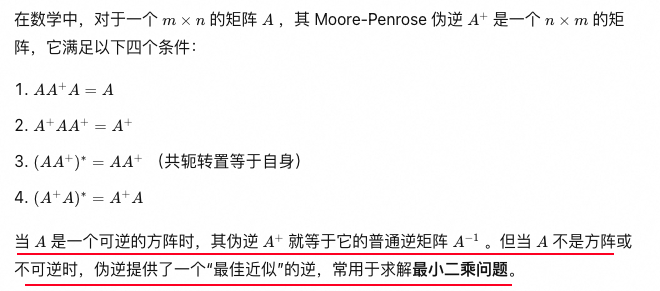

In [99]:
Image(filename="./Image/Moore-Penrose.png")

##### torch.pinverse 的使用与参数

```python
torch.pinverse(input, rcond=1e-15)
```
- input：
  - 输入张量，可以是任意形状的矩阵或批量矩阵。
- rcond：
  - 奇异值截断阈值（可选，默认 1e-15）。所有小于 rcond * max(singular_values) 的奇异值会被视为零。这个参数对数值稳定性至关重要。

In [101]:
# 非方阵示例 (3x2)
A = torch.tensor([[1.0, 2.0],
                  [3.0, 4.0],
                  [5.0, 6.0]])
A_pinv = torch.pinverse(A)
print('伪逆形状：',A_pinv.shape)

# 验证： A @ A_pinve @ A
reconstruted = A @ A_pinv @ A
print('重构误差：',torch.norm(A - reconstruted).item()) # 应该接近0

# 输出： 0.0000032798807296785526

伪逆形状： torch.Size([2, 3])
重构误差： 3.2798807296785526e-06


**为什么需要伪逆？实际应用场景**
1. 线性回归与最小二乘：
   - 当方程组 Ax=b 无精确解时（如超定系统），伪逆给出最小范数最小二乘解 $x=A^+b$ 。
2. 处理奇异矩阵：
   - **当矩阵行列式为0时，torch.inverse() 会报错，而 torch.pinverse() 仍能返回一个有意义的解**。
3. 神经网络中的权重更新：
   - 在某些优化算法或注意力机制中，需要处理可能秩亏的矩阵，**伪逆提供了数值稳定的解决方案。**
4. 数据降维与特征提取：
   - **在主成分分析（PCA）等方法中，伪逆可用于计算投影矩阵**。

**注意事项与最佳实践**
- 数值稳定性：
  - 默认的 rcond=1e-15 可能过于严格或宽松。如果结果不理想，可以尝试调整该值（如 1e-10 或 1e-8）。
- 性能考量：
  - 伪逆基于 SVD 分解，计算成本高于普通逆矩阵。对于可逆方阵，优先使用 torch.inverse()。
- 批量支持：
  - torch.pinverse() 支持批量矩阵输入，形状为 (*, m, n)，输出形状为 (*, n, m)。

#### torch.det(A)     行列式

- torch.det(A) 是 PyTorch 中用于计算**方阵行列式**（Determinant）的函数。
  - 正如我们之前讨论矩阵求逆时提到的，<font color='red'>行列式是判断一个矩阵是否可逆、以及衡量矩阵变换“体积缩放比例”的核心指标。</font>
  
#####  基础用法与代码示例

In [103]:
# 创建一个 3x3 的方阵
A = torch.tensor([[1.0, 2.0, 3.0],
                  [4.0, 5.0, 6.0],
                  [7.0, 8.0, 10.0]])

# 计算行列式
det_A = torch.det(A)
print(det_A)

tensor(-3.0000)


##### 核心特性
- 输入限制：
  - 必须是方阵（**即最后两个维度必须相等**，如 (*, n, n)）。
- 输出形状：
  - <font color='red'>返回一个标量</font>（如果是批量矩阵，则返回形状为 * 的张量）。
- 数据类型：
  - **输入张量必须是浮点型（float32, float64）或复数类型**。

##### 行列式的几何与代数意义（复习与深化）
- 几何意义（体积缩放）： 
  - ∣det(A)∣ 代表矩阵 A 对空间进行线性变换后，单位体积的缩放倍数。如果 det(A)=3 ，说明变换后的体积是原来的 3 倍。
  
- 符号意义（方向翻转）：
  - det(A)>0 ：保持了空间的“手性”（如右手系依然是右手系）。
  - det(A)<0 ：空间发生了镜像翻转（如左手系变成了右手系）。
  
- 代数意义（奇异性判断）：
  - det(A)=0 ：矩阵是奇异的（Singular），发生了维度坍塌，不可逆。
  - det(A)≠0 ：矩阵是非奇异的，可逆。 
  
##### ⚠️ <font color='red'>深度学习中的工程避坑指南</font>

虽然 torch.det 在数学上很直观，但在实际的神经网络训练中，极少直接对原始矩阵调用它，原因如下：

**A. 数值溢出/下溢风险**
- 行列式的值等于矩阵所有特征值的乘积。
- **如果矩阵维度很大（比如 1000×1000 ）**，即使每个特征值只有 1.1，乘积也会是 $1.1^{1000}≈10^{41}$，直接导致浮点数 Inf（溢出）；
- 反之如果特征值小于 1，则会导致 0（下溢）。

**B. 最佳替代方案：Log-Determinant**
在深度学习中，我们通常计算的是**行列式的对数**（Log-Determinant），<font color='red'>即将连乘转化为连加</font>，完美解决数值溢出问题：

$log(det(A))=∑log(λ_i)$

PyTorch 提供的专用函数：torch.linalg.slogdet(A)
- 它返回一个包含两个元素的元组 (sign, logabsdet)，即符号和对数绝对值。**这是极其稳定且常用的做法。**

In [ ]:
# 推荐做法
sign, logabsdet = torch.linalg.slogdet(A)
print(f"符号: {sign}, 对数绝对值: {logabsdet}")

**C. 梯度计算**
- torch.det(A) 是支持自动求导的。如果 A 是可导张量，PyTorch 会利用雅可比公式（Jacobi's formula）自动计算 det(A) 对 A 的梯度。但在反向传播时，如果det(A) 接近 0，梯度会趋于无穷大，导致训练崩溃。

#####  总结
- torch.det(A) 是计算方阵行列式的直接工具，常用于小维度矩阵的数学验证或判断矩阵是否可逆。
  - <font color='red'>但在大模型和深度学习的实际训练中，为了避免数值灾难，请务必使用 torch.linalg.slogdet 来计算对数行列式。</font>

#### torch.trace()矩阵的痕迹

在 PyTorch 中，torch.trace(input) 是用于计算矩阵迹（Trace）的函数。矩阵的迹在数学上通常记作 tr(A) 或 Tr(A) ，
- 它的定义非常直观：<font color='red'>矩阵主对角线（从左上角到右下角）上所有元素的总和。</font>

##### 基础用法与代码示例
torch.trace 只需要传入一个至少是二维的张量即可。

In [104]:
# 创建一个 3x3 的方阵
A = torch.tensor([[1, 2, 3], 
                  [4, 5, 6], 
                  [7, 8, 9]])

# 计算痕迹： 主对角线元素为1，5,9
trace_A = torch.trace(A)
print(trace_A)

tensor(15)


##### 核心特性与注意事项
- 非方阵也支持：
  - 虽然迹在严格的数学定义中通常针对方阵，但 PyTorch 的 torch.trace 对非方阵同样有效。**它会自动提取主对角线上的元素（即行索引和列索引相等的元素）并求和**。

In [ ]:
# 2x3 的非方阵，主对角线元素为 1, 5
B = torch.tensor([[1, 2, 3], 
                  [4, 5, 6]])
print(torch.trace(B))  # 输出: tensor(6)

- 高维张量的批量处理：如果输入是一个多维张量（如 4D 张量），torch.trace 会默认对最后两个维度（即矩阵维度）计算迹，并返回一个降维后的张量。

In [ ]:
# 形状为 (3, 4, 4, 5) 的张量
C = torch.randn(3, 4, 4, 5)
trace_C = torch.trace(C)
print(trace_C.shape)  # 输出: torch.Size([3, 5])

- <font color='red'>迹的深层数学意义</font>
**为什么在深度学习中我们需要关注矩阵的迹？它不仅仅是对角线求和，还具有以下深刻的数学性质**：

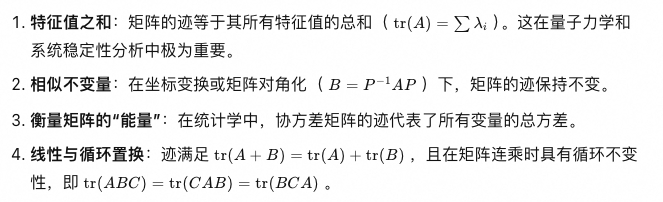

In [105]:
Image(filename='./Image/torch_trace.png')

##### 深度学习中的实际应用

结合你之前问过的 PPO 和 DPO，torch.trace 在实际算法中有非常具体的应用：

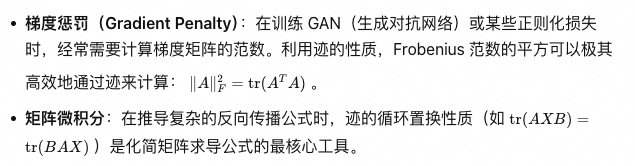

In [106]:
Image(filename='./Image/torch_trace1.png')

##### 总结
- torch.trace 是一个轻量但数学内涵丰富的函数。如果你只是需要计算对角线之和，它是最直接的函数；
  - **但如果你在处理高维批量张量，或者想提取更复杂的对角线元素，PyTorch 还提供了更灵活的 torch.diagonal() 配合 .sum() 来实现。**

#### torch.eig(A)        特征值分解

- 在 PyTorch 中，计算矩阵特征值和特征向量的正确函数是 **torch.linalg.eig(A)**（注意：旧版的 torch.eig() 已被弃用）。
- **特征值分解（Eigenvalue Decomposition）是线性代数中的核心概念，也是深度学习、数据分析和物理建模的重要工具。**以下为你详细拆解它的用法、数学意义以及工程实践中的避坑指南。

##### 基础用法与代码示例
torch.linalg.eig(A) 用于计算方阵（或一批方阵）的特征值分解，并返回一个包含特征值和特征向量的元组。

In [107]:
import torch

# 创建一个 3x3 的实数方阵
A = torch.randn(3, 3)

# 计算特征值分解
eigenvalues, eigenvectors = torch.linalg.eig(A)

print("特征值:\n", eigenvalues)
print("特征向量:\n", eigenvectors)

特征值:
 tensor([-0.6843+0.0000j,  0.5346+0.8358j,  0.5346-0.8358j])
特征向量:
 tensor([[ 0.9498+0.0000j, -0.1903+0.2890j, -0.1903-0.2890j],
        [ 0.3100+0.0000j, -0.7418+0.0000j, -0.7418-0.0000j],
        [ 0.0431+0.0000j,  0.4368-0.3732j,  0.4368+0.3732j]])


##### 核心数学意义：<font color='red'>矩阵的“解剖学”</font>
<font color='blue'>特征值分解的本质是将一个复杂的矩阵变换，拆解为几个简单的、相互独立的缩放（Scaling）操作</font>。
- 数学公式： 
  - Av=λv
- 直观理解：
  - <font color='red'>如果把矩阵 A 看作一个“变换机器”，当它作用于某些特殊的向量 v （特征向量）时，这些向量的方向不会改变，仅仅是被拉伸或压缩了，而这个拉伸/压缩的倍数就是 λ （特征值）。</font>
- 矩阵重构：
  - 如果矩阵可对角化，它可以被分解为 $A=QΛQ^−1$。其中 Q 是由特征向量组成的矩阵， Λ 是由特征值组成的对角矩阵。
  
##### <font color='red'>深度学习与机器学习中的应用</font>

特征值分解在 AI 领域有着极其广泛的应用：
- 主成分分析（PCA）与降维：
  - 通过计算数据协方差矩阵的特征值和特征向量，**可以找到数据方差最大的方向（即主成分）**。保留最大特征值对应的特征向量，就能在保留最多信息的前提下降低数据维度。
  
- 系统稳定性分析：
  - 在由线性微分方程描述的动态系统中，系统矩阵的特征值决定了系统的稳定性。例如，如果所有特征值的实部都为负数，系统是稳定的。
- 谱聚类（Spectral Clustering）：
  - 利用图拉普拉斯矩阵的特征向量对数据进行聚类，非常适合处理非凸形状的数据。

##### ⚠️ <font color='red'>工程实践中的“坑”与最佳实践</font>
在实际使用 torch.linalg.eig 时，有几个极其重要的注意事项：

**A. 结果总是复数（Complex-valued）**
这是新手最容易踩坑的地方。
- **即使你的输入矩阵 A 是纯实数（Float），返回的特征值和特征向量通常也是复数类型（cfloat 或 cdouble）**。
- 原因：实数矩阵也可能存在复数特征值（例如旋转矩阵）。
- 处理技巧：**如果你确定矩阵的特征值一定是实数，可以通过 .real 属性提取实部：**

In [ ]:
real_eigenvalues = eigenvalues.real

**B. 必须是方阵**
- torch.linalg.eig 要求输入必须是 n×n 的方阵。如果传入长方形矩阵，程序会直接报错。如果你处理的是非方阵，请使用 SVD（奇异值分解）：torch.linalg.svd()。

**C. 对称矩阵的“超级加速”**
如果你的矩阵是对称矩阵（Symmetric）或埃尔米特矩阵（Hermitian），千万不要用 torch.linalg.eig！
- 正确做法：请使用 torch.linalg.eigh(A)。
- 优势：eigh 针对对称矩阵进行了底层优化，计算速度更快、数值更稳定，而且直接返回实数，省去了处理复数的麻烦。

**D. 反向传播的 NaN 陷阱**
- 如果你的矩阵存在“重特征值”（即多个特征值完全相同），在进行反向传播（Backpropagation）时，计算梯度可能会出现 NaN。在将其作为深度学习模型的一层使用时需格外小心。

##### 总结
torch.linalg.eig(A) 是探索矩阵内在结构的强大工具。但在实际编码中，请务必牢记：先判断矩阵是否对称（对称用 eigh），再判断是否为方阵（非方阵用 svd），最后注意处理复数返回值。

#### torch.svd(A)    奇异值分解

在 PyTorch 中，torch.svd(A) 用于计算矩阵的奇异值分解（Singular Value Decomposition, SVD）。正如我们之前讨论特征值分解（EVD）时提到的，EVD 只能作用于方阵，而 SVD 是特征值分解在奇异矩阵（非方阵）上的推广形式，它可以对任意 m×n 的矩阵进行分解。
以下为你详细拆解它的用法、数学意义以及极其重要的工程避坑指南。
##### 基础用法与代码示例
SVD 的核心思想是将一个矩阵 A 分解为三个矩阵的乘积：$ A=UΣV^T$ 。在 PyTorch 中，你可以这样使用：

In [ ]:
import torch

# 创建一个 3x2 的非方阵
A = torch.tensor([[1.0, 2.0], 
                  [3.0, 4.0], 
                  [5.0, 6.0]])

# 计算奇异值分解
U, S, V = torch.svd(A)

print("左奇异向量矩阵 U:\n", U)
print("奇异值向量 S:\n", S)
print("右奇异向量矩阵 V:\n", V)

##### 核心数学意义：矩阵的“解剖学”
- SVD 将任意矩阵拆解为三个具有明确几何意义的部分：U (左奇异向量矩阵)：一个 m×m 的正交矩阵（酉矩阵），代表数据在行空间的主方向。

- Σ (奇异值矩阵)：一个包含奇异值的对角矩阵。在 PyTorch 中，S 通常直接返回一个一维向量（按从大到小降序排列的非负实数）。奇异值代表了各个主方向上的“能量”或信息权重，值越大说明该方向上的信息越重要。

- V (右奇异向量矩阵)：一个 n×n 的正交矩阵，代表数据在列空间的主方向。

##### 深度学习中的广泛应用
SVD 是机器学习和数据分析领域的“瑞士军刀”：
- 数据降维与压缩（PCA）：
  - 通过保留前 k 个最大的奇异值及其对应的奇异向量，可以构造矩阵的低秩近似。这能最大程度保留关键信息的同时，大幅减少存储空间和计算量。
- 数据去噪：
  - 噪声信息通常对应较小的奇异值。通过剔除这些小奇异值，可以有效提升数据质量。
- 推荐系统与协同过滤：
  - 利用矩阵分解思想，SVD 可以预测用户对物品的评分等缺失值，实现个性化推荐。
- 计算矩阵的伪逆：
  - SVD 是计算 Moore-Penrose 伪逆（即 torch.pinverse 的底层原理）的标准方法。
  
##### ⚠️ 工程实践中的“坑”与最佳实践（极其重要）
在实际编码中，关于 torch.svd 有几个必须牢记的注意事项：
**A. 强烈建议使用新 API：torch.linalg.svd**
torch.svd() 是旧版 API，强烈建议使用 torch.linalg.svd() 来代替。新 API 更稳定、功能更完善，而旧 API 在未来的 PyTorch 版本中可能会被弃用。
**B. 返回值的关键区别（V vs Vh）**
这是从旧 API 迁移到新 API 时最容易出错的地方：
- 旧 API (torch.svd)：返回 U, S, V（即右奇异向量矩阵本身）。
- 新 API (torch.linalg.svd)：返回 U, S, Vh。这里的 Vh 是 V 的转置（如果是复数矩阵则是共轭转置）。
  - 如果你在新 API 中需要原本的 V 矩阵，需要自己进行转置操作：V = Vh.t()。
**C. 仅计算奇异值的高效方法**
如果你只关心奇异值 S （例如用于计算矩阵的秩或条件数），而不需要 U 和 V ，计算完整的 SVD 会浪费大量时间和内存。
- 最佳实践：
  - 使用 torch.linalg.svdvals(A)。它只返回奇异值，不仅速度更快，而且在反向传播时梯度更稳定。
**D. 符号的非唯一性（Sign Ambiguity）**
SVD 在数学上是非唯一的。如果 $(U,S,V^T)$ 是一个分解，那么 $(−U,S,−V^T)$ 也是正确的分解。这意味着在不同设备（CPU/GPU）或不同 PyTorch 版本下，返回的 U 和 
V 的列可能会相差一个正负号。这是完全正常的数学现象，但在进行单元测试或比较结果时需要注意。

##### 总结
SVD 是处理任意矩阵最强大的线性代数工具。在实际工程中，请优先使用 torch.linalg.svd，牢记它返回的是 Vh 而不是 V，并且在只需要奇异值时使用 torch.linalg.svdvals 以获得最佳性能。

#### torch.cholesky(A)         # Cholesky 分解（需正定）

# 归约操作（Reduce）

## 求和、平均

### A.sum()    所有元素之和

In [1]:
import torch
A = torch.tensor([[1, 2, 3],
                  [4, 5, 6]])

A_sum = A.sum()
print(A_sum)

tensor(21)


### A.sum(dim=1)  沿行求和（压缩列维度）
- 就是把每一行的元素加起来。

In [113]:
A_sum_dim = A.sum(dim=1)
print(A_sum_dim)

tensor([ 6, 15])


### A.mean(dim=0) —— 沿列求平均（压缩行维度）
- 就是计算每一列的平均值。

In [114]:
A_sum_dim = A.sum(dim=0)
print(A_sum_dim)

tensor([5, 7, 9])


### A.prod(dim=1) —— 沿行连乘
- dim=1 表示沿着列方向，将每一行的元素相乘。
- 计算：
  - 第0行：1 × 2 × 3 = 6
  - 第1行：4 × 5 × 6 = 120

In [115]:
A_prod = A.prod(dim=1)
print(A_prod)

tensor([  6, 120])


### 核心记忆法则：<font color='red'>dim 的本质是什么？</font>

很多初学者容易把 dim=0 和 dim=1 搞混。你只需要记住一个底层逻辑：
<font color='red'>dim 参数指的是“被压缩（消除）的维度”</font>
- 当你指定 dim=0 时，系统会跨越第0维度（行）去收集数据进行计算，计算完成后，**第0维度就消失了**。
- 当你指定 dim=1 时，系统会跨越第1维度（列）去收集数据，计算完成后，**第1维度就消失了**。

**补充提示：**
- 如果你希望计算后保留原有的维度数（例如形状从 (2, 3) 变成 (2, 1) 而不是 (2,)），**可以在函数中加入 keepdim=True 参数**，这在后续张量广播（Broadcasting）运算时非常有用。

## 最大/最小
- A.max(), A.min()     全局最大/最小
- A.max(dim=1)         返回 (values, indices)
- A.argmax(dim=1)      仅返回最大值的索引

In [118]:
A_max = A.max()
print(A_max)

# 指定 dim=1 表示沿着列的方向（即第1维度），在每一行中寻找最大值。
# 返回值特性（重点）：与 sum 或 mean 不同，max(dim=...) 会返回一个包含两个元素的元组 (tuple)：
A_max_1 = A.max(dim=1)
print(A_max_1)

tensor(6)
torch.return_types.max(
values=tensor([3, 6]),
indices=tensor([2, 2]))


In [117]:
A_min = A.min()
print(A_min)

tensor(1)


In [2]:
A_argmax_1 = A.argmax(dim=1)
# 仅返回最大值的索引
print(A_argmax_1)

tensor([2, 2])


### 核心对比与实战建议：max vs argmax
#### 什么时候用 A.max(dim=...)？
  - 当你既需要知道最大值是多少，又需要知道它在哪时使用。
    - **比如在自然语言处理（NLP）的注意力机制（Attention）中，你不仅要知道最大的注意力权重在哪，还需要提取这个权重的具体数值**。
  
#### 什么时候用 A.argmax(dim=...)？
  - 当你只关心“谁是冠军”（**位置**），不关心“冠军的分数”时使用。这在深度学习中最经典的场景就是分类任务。
    - 实战举例：假设模型输出的是 3 个类别的得分（logits），例如 scores = tensor([0.2, 0.9, 0.5])。你不需要知道最高分是 0.9，你只需要知道得分最高的类别索引是 1，此时直接使用 scores.argmax(dim=0) 即可得到预测类别。
    
### ⚠️ 避坑指南：多个最大值怎么办？
如果在某一行或某一列中，**存在多个相同的最大值**，
- **max() 和 argmax() 都只会返回第一个出现的最大值的索引**。例如：

In [3]:
B = torch.tensor([10, 2, 10, 5])
print(B.argmax())  # 输出: tensor(0)，而不是同时返回 0 和 2

tensor(0)


**如果你需要找出所有最大值的位置**，
- 需要结合布尔筛选（如 torch.eq(B, B.max())）来额外处理。

## 累积
- A.cumsum(dim=0)           # 累积和
- A.cumprod(dim=1)          # 累积积

### A.cumsum(dim=0) —— 沿行方向累积和

- dim=0 表示沿着第0维度（即垂直向下，按列）进行累积相加。
- 通俗地说，就是**把当前元素加上它正上方所有元素的和**。

**实际应用场景**：
- 在时间序列分析中计算“累计销售额”或“累计利润”；在概率论中，对概率质量函数（PMF）求累积和可以得到累积分布函数（CDF）。

In [4]:
A = torch.tensor([[1, 2, 3],
                  [4, 5, 6]])

A_cumsum = A.cumsum(dim=0)
print(A_cumsum)

tensor([[1, 2, 3],
        [5, 7, 9]])


### A.cumprod(dim=1) —— 沿列方向累积积
- 含义：dim=1 表示沿着第1维度（即水平向右，按行）进行累积相乘。通俗地说，就是当前元素乘以它左侧所有元素的积。

In [5]:
A_cumprod = A.cumprod(dim=1)
print(A_cumprod)

tensor([[  1,   2,   6],
        [  4,  20, 120]])


## 拼接与拆分

### 拼接
- torch.cat([A, B], dim=1)      # 沿列拼接 → [2, 6]
- torch.stack([A, B], dim=0)    # 新增维度 → [2, 2, 3]

In [8]:
A = torch.tensor([[1, 2, 3],
                  [4, 5, 6]])

B = torch.tensor([[7, 8, 9],
                  [10, 11, 12]])

#### torch.cat([A, B], dim=1) —— 沿现有维度拼接（胶水）
- 核心含义：cat（Concatenate）的作用是在现有的维度上进行延伸。它不会增加张量的总维度数，就像用胶水把两块积木拼成一块更大的积木。
- 参数解析：dim=1 表示沿着第1维度（即水平方向，按列）进行拼接。通俗地说，就是把 B 拼接到 A 的右侧。
- 形状变化：原始形状为 (2, 3)，在第1维度拼接后，列数相加（3+3=6），行数不变。输出形状变为 (2, 6)

In [9]:
cat_A_B = torch.cat([A, B], dim=1)
print(cat_A_B)

tensor([[ 1,  2,  3,  7,  8,  9],
        [ 4,  5,  6, 10, 11, 12]])


#### torch.stack([A, B], dim=0) —— <font color='red'>新增维度堆叠（层叠）</font>
- 核心含义：stack 会在指定的位置创建一个全新的维度，然后将输入的张量在这个新维度上“叠”起来。你可以把它想象成把两张扑克牌叠在一起，形成了一叠牌。
- 参数解析：dim=0 表示在最前面（第0维的位置）插入一个新维度。
- 形状变化：原始形状为 **(2, 3)**，插入新维度后，张量从 2D 变成了 3D。新维度的长度等于参与堆叠的张量数量（这里是2个）。输出形状变为 **(2, 2, 3)**。

In [10]:
stack_A_B = torch.stack([A,B],dim=0)
print(stack_A_B)

tensor([[[ 1,  2,  3],
         [ 4,  5,  6]],

        [[ 7,  8,  9],
         [10, 11, 12]]])


##### 底层等价证明：
- stack 的本质其实就是 unsqueeze + cat。你可以用代码验证：

In [11]:
# 手动将A和B升维，从(2,3)变为(1,2,3)
A_un = A.unsqueeze(0)
B_un = B.unsqueeze(0)

# 沿第0维拼接
res_manul = torch.cat([A_un,B_un],dim=0)

# 结果与stack完全一致
print(torch.equal(res_manul,torch.stack([A,B],dim=0)))

True


### 核心对比与底层逻辑
为了帮你彻底理清这两个函数，可以参考以下对比：

| 特性 | torch.cat | torch.stack |
| :--- | :--- | :--- |
| 维度数量 | 保持不变 | **增加 1 维** |
| 输入约束 | 仅拼接维可不等，其余必相等 | 所有维度必须完全相等 |
| 底层逻辑 | 在现有轴上延伸 |** 先 `unsqueeze` 升维，再 `cat` 拼接** |
| 典型应用 | 特征融合、通道拼接、扩充数据 | 构建 Batch、多分支网络、序列建模 |

### 🚀 深度学习中的实战场景
#### 什么时候用 torch.cat？
  - 特征融合（Feature Fusion）：
    - 在 U-Net 等经典网络中，经常需要将编码器（Encoder）提取的浅层特征和解码器（Decoder）的深层特征在通道维度（通常是 dim=1）拼接起来，让网络同时利用全局和局部信息。
  - 数据增强：
    - 将原始图片和翻转后的图片在 Batch 维度拼接，扩充训练数据。
    
#### 什么时候用 torch.stack？
  - 构建 Batch：
    - 在数据加载（DataLoader）时，将单张 2D 图像 (C, H, W) 堆叠成 3D 的批次张量 (**N**, C, H, W)。
  - 多分支决策（如 SKAttention）：
    - 将不同卷积核处理后的结果堆叠起来，以便后续通过 softmax 算出每个分支的权重。
  - 序列处理：
    - 将一帧一帧的 2D 图像叠成 3D 的视频片段张量。

### 拆分
- torch.split(A, 2, dim=1)  按“每块的大小”切（例如：每 2 个切一刀） 
- torch.chunk(A, 2, dim=0)  按“总块数”切（例如：切成 2 份）

In [14]:
A = torch.tensor([[1, 2, 3, 4, 5, 6],
                  [7, 8, 9, 10, 11, 12]])

#### torch.split(A, 2, dim=1) —— 按固定大小拆分
- 含义：沿着第 1 维度（列方向），每隔 2 个元素切一刀。
- 参数解析：
  - split_size_or_sections=2：指定每一块的大小是 2。
  - dim=1：沿着列切。
  
- 计算过程：
  - 第 1 块：取索引 0~1 列 → [1, 2] 和 [7, 8]
  - 第 2 块：取索引 2~3 列 → [3, 4] 和 [9, 10]
  - 第 3 块：取索引 4~5 列 → [5, 6] 和 [11, 12]

In [15]:
split_A = torch.split(A,2,dim=1)
print(split_A)

(tensor([[1, 2],
        [7, 8]]), tensor([[ 3,  4],
        [ 9, 10]]), tensor([[ 5,  6],
        [11, 12]]))


- 进阶用法：如果传入列表 [1, 2, 3]，则分别切出大小为 1、2、3 的三块

#### torch.chunk(A, 2, dim=0) —— 按数量均分
- 含义：沿着第 0 维度（行方向），将张量平均分成 2 块。
- 参数解析：
  - chunks=2：指定要切成的总块数。
  - dim=0：沿着行切。
- 计算过程：
  - 总行数是 2，要切成 2 块 → 每块分得 1 行。
  - 第 1 块：第 0 行 → [1, 2, 3, 4, 5, 6]
  - 第 2 块：第 1 行 → [7, 8, 9, 10, 11, 12]
- 输出结果：返回一个包含 2 个 张量的元组，每个张量形状为 (1, 6)

In [ ]:
chunk_A = torch.chunk(A,2,dim=0)
print(chunk_A)

##### ⚠️ 注意事项：
- 如果无法整除（例如 5 行切成 2 块），PyTorch 不会报错，而是让前面的块大一点，最后的块小一点（例如变成 3 行 + 2 行）。 

#### 💡 核心对比总结

| 特性 | `torch.split` | `torch.chunk` |
| :--- | :--- | :--- |
| 切分依据 | 块的大小 (Size) | 块的数量 (Count) |
| 第二个参数 | `split_size` (int 或 list) | `chunks` (int) |
| 典型场景 | <font color='red'>处理固定大小的 Batch 数据</font> | <font color='red'>将任务均分给多个 GPU/线程 </font>|
| 记忆口诀 | <font color='blue'>"我要每块多大？"</font> | <font color='blue'>"我要切成几份？"</font> |



## 广播（Broadcasting）
PyTorch 自动支持广播，规则与 NumPy 一致： 

In [19]:
A = torch.randn(3, 4)
b = torch.randn(4)            # [4]

A_b = A + b                         # b 自动广播为 [3, 4]
print(A_b)
A_n = A + 5                         # 标量广播
print(A_n)

# 显式扩展
b.unsqueeze(0).expand(3, 4)   # [4] → [1,4] → [3,4]

tensor([[-2.5455,  1.2261,  0.6969,  0.0286],
        [-0.5442,  1.6644,  1.1077, -1.8806],
        [-1.8294,  1.7217,  0.2778,  1.8981]])
tensor([[3.3653, 5.1983, 5.7411, 5.4131],
        [5.3666, 5.6367, 6.1519, 3.5040],
        [4.0814, 5.6940, 5.3220, 7.2826]])


tensor([[-0.9107,  1.0277, -0.0442, -0.3845],
        [-0.9107,  1.0277, -0.0442, -0.3845],
        [-0.9107,  1.0277, -0.0442, -0.3845]])

## 内存与设备操作

### 设备转移

In [ ]:
A.cuda()                      # 移到 GPU
A.cpu()                       # 移到 CPU

A.to('cuda:1')                # 指定 GPU
A.to(torch.float16)           # 改变数据类型

### 内存布局
#### A.contiguous()    保证内存连续

A.contiguous() 是 PyTorch 中用于确保张量在内存中物理连续存储的关键方法。它的核心作用是：当张量经过 transpose、permute、view 等操作后，虽然逻辑形状改变，但底层数据在内存中的排列可能变得“跳跃”或“不连续”，此时调用 .contiguous() 会复制数据并重新排列成连续内存块，从而满足后续操作（如 view()）对内存布局的强制要求。
##### 为什么需要 contiguous()？
- PyTorch 的张量默认以行优先（Row-Major）方式存储在内存中。当你执行 transpose(0,1) 或 permute(2,0,1) 时，PyTorch 不会移动实际数据，而是修改张量的“步长”元数据来改变访问顺序。这导致逻辑上相邻的元素在物理内存中可能相隔很远。

In [ ]:
x = torch.arange(6).reshape(2, 3)  # [[0,1,2], [3,4,5]]，内存连续: 0,1,2,3,4,5
y = x.transpose(0, 1)              # [[0,3], [1,4], [2,5]]，逻辑上按列读，但内存仍是 0,1,2,3,4,5

此时 y 是非连续的。如果你尝试 y.view(6)，PyTorch 会报错，因为它无法按行优先顺序从跳跃的内存中读取数据。

contiguous() 的行为规则
- 如果张量已经是连续的 → 直接返回自身，无额外开销。
- 如果张量是非连续的 → 创建一个新张量，将数据按逻辑顺序复制到一块新的连续内存中，并返回这个新张量。
- 返回值：总是返回一个内存连续的张量，可能与原张量共享数据（如果原张量已连续），也可能是全新副本。

##### 场景一：transpose 后必须 view 

In [ ]:
x = torch.randn(2, 3, 4)
y = x.transpose(1, 2)        # shape: (2,4,3)，非连续
# z = y.view(2, -1)          # ❌ 报错！RuntimeError: view size is not compatible...
z = y.contiguous().view(2, -1) # ✅ 正确！先确保内存连续，再 reshape

##### 场景二：多头注意力机制中的维度重排

In [ ]:
# 假设输入 shape: (batch, seq_len, hidden_dim)
x = torch.randn(2, 6, 768)
# 转置后用于分头
x_trans = x.transpose(1, 2)   # (2, 768, 6)，非连续
# 必须 contiguous 才能安全 view 成多头格式
x_heads = x_trans.contiguous().view(2, 12, 64, 6)  # 12头，每头64维

##### 性能优化 —— 避免隐式拷贝

In [ ]:
# 错误做法：每次循环都调用 contiguous()，即使它已经连续
for batch in dataloader:
    x = batch['data'].contiguous()  # 如果 batch['data'] 已经连续，这是浪费
    ...

# 正确做法：只在必要时调用
if not x.is_contiguous():
    x = x.contiguous()

**contiguous() vs reshape()**
- reshape() 会自动处理非连续情况（内部可能调用 contiguous()），所以更安全但可能有隐藏拷贝开销。
- view() 要求输入必须连续，否则报错，但零拷贝、性能更高。
- 最佳实践：如果你确定张量已连续（如刚创建或刚 cat），用 view()；如果不确定或经过变换，用 reshape() 或显式 contiguous().view()。

##### 如何检查张量是否连续？
使用 .is_contiguous() 方法：

In [ ]:
x = torch.randn(3, 4)
print(x.is_contiguous())       # True

y = x.transpose(0, 1)
print(y.is_contiguous())       # False

z = y.contiguous()
print(z.is_contiguous())       # True

##### 总结
A.contiguous() 是 PyTorch 中保障内存布局安全的“保险丝”。它在以下情况至关重要：
- 你计划对张量使用 view()；
- 你将张量传入要求连续内存的底层算子（如某些 CUDA kernel）；
- 你在调试因内存不连续导致的奇怪错误或性能瓶颈。
记住：transpose/permute 不改数据，只改索引；contiguous 才真正重排数据。 在高性能计算和模型部署中，合理使用它可以避免不必要的内存拷贝，提升效率。

#### A.clone() 
- 是 PyTorch 中用于创建张量深拷贝的核心方法，它会生成一个与原张量形状、数据类型、设备完全相同但不共享内存的新张量，同时保留梯度回溯能力，是处理计算图、避免梯度污染或内存冲突的关键操作。

#####  核心特性与行为规则
- 内存独立性：
  - 新张量与原张量拥有独立的内存地址，修改克隆后的张量不会影响原张量。
- 梯度可回溯：
  - 如果原张量 requires_grad=True，克隆后的新张量会保留 grad_fn=\<CloneBackward>，其梯度在反向传播时会叠加回原张量。
- 非叶子节点：
      - 克隆后的新张量不是叶子节点，因此不能直接访问 .grad 属性。
- 设备与类型一致：
      - 自动继承原张量的 device（CPU/GPU）和 dtype（如 float32）。
    
##### 典型使用场景与代码示例
**场景一：避免梯度污染（推荐用法）**
在 GAN、强化学习或多任务训练中，常需对同一张量进行多次独立计算。直接复用会导致梯度叠加错误，此时应使用 detach().clone()：

In [ ]:
import torch

x = torch.tensor([1.0, 2.0], requires_grad=True)

# ❌ 错误做法：直接复用 x，梯度会叠加
y1 = x * 2
y2 = x * 3
y1.sum().backward()
y2.sum().backward()
print(x.grad)  # tensor([5., 5.]) —— 期望是 [2,3]，但实际是 2+3=5

# ✅ 正确做法：使用 detach().clone() 切断梯度并复制
x_clone = x.detach().clone()
y1 = x * 2
y2 = x_clone * 3
y1.sum().backward()
y2.sum().backward()
print(x.grad)  # tensor([2., 2.]) —— 仅保留 y1 的梯度

**场景二：保存中间状态用于日志或可视化**
在训练过程中，若想记录某个中间张量的值而不影响后续计算图：

In [ ]:
intermediate = model.layer(x).clone()  # 保存当前值，不影响后续反向传播
log_value = intermediate.mean().item()  # 安全提取数值

##### 与其他拷贝操作的对比

| 操作 | 内存共享 | 梯度回溯 | 适用场景 |
| :--- | :--- | :--- | :--- |
| `clone()` | 否 | 是 | 需要保留梯度路径的深拷贝 |
| `detach().clone()` | 否 | 否 | 完全独立副本，常用于 GAN/RL |
| `copy_()` | 是（原地） | 是 | 原地修改，不创建新张量 |
| `data` | 是 | 否 | 已弃用，不推荐使用 |

##### 注意事项
- 性能开销：clone() 会分配新内存并复制数据，频繁调用可能影响性能，尤其在大规模张量上。
- 组合使用：若只需数值副本且无需梯度，优先使用 detach().clone()，避免不必要的梯度计算图构建。
- 避免误用：不要将 clone() 用于“视图”操作（如 view），它不是零拷贝操作。

#### A.detach()                  切断计算图（不求梯度）

## 常用快捷对照表

| 操作          | PyTorch 方法                          |
| :---------- | :---------------------------------- |
| 矩阵乘法        | `A @ B`, `torch.matmul(A, B)`       |
| 逐元素乘        | `A * B`, `torch.mul(A, B)`          |
| 转置          | `A.T`, `A.t()`, `A.transpose(0, 1)` |
| 求逆          | `torch.inverse(A)`                  |
| SVD         | `torch.svd(A)`                      |
| 求迹          | `torch.trace(A)`                    |
| 对角线         | `torch.diag(A)`, `A.diag()`         |
| 外积          | `torch.outer(u, v)`                 |
| Kronecker 积 | `torch.kron(A, B)`                  |
